# Phase 1: Deep Q-Learning (DQN) Baseline

### Step 1: Environment Setup and Replay Buffer
To establish our baseline, we first implement a standard Deep Q-Network (DQN). 
Because `MountainCar-v0` gives a sparse reward of `-1` for every step, random $\epsilon$-greedy exploration often fails to reach the flag before timing out. To ensure our algorithms can train quickly on a CPU, we wrap the environment to include **Reward Shaping**. We provide a small bonus based on the car's mechanical energy (height/position) to guide it out of the valley.

For DQN, we also need an **Experience Replay Buffer** to break the temporal correlation of sequential environment interactions. We store `(state, action, reward, next_state, done)` tuples and sample them randomly during training.

In [1]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import random
from collections import deque
import matplotlib.pyplot as plt
from IPython.display import clear_output

# --- 1. Environment Wrapper with Reward Shaping ---
class ShapedMountainCar(gym.Wrapper):
    """
    Adds reward shaping to MountainCar to help algorithms train faster.
    No safety constraints are applied yet.
    """
    def __init__(self, env):
        super().__init__(env)
        
    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        
        # Reward Shaping: Encourage gaining height (position is obs[0])
        # The bottom of the valley is at -0.5
        height_bonus = abs(obs[0] - (-0.5)) * 1.5
        shaped_reward = reward + height_bonus
        
        # Completion Bonus: Massive payout for reaching the flag
        if terminated:
            shaped_reward += 100.0
            
        return obs, shaped_reward, terminated, truncated, info

# --- 2. DQN Replay Buffer ---
class DQNReplayBuffer:
    """Fixed-size buffer to store experience tuples."""
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)
    
    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
    
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = zip(*batch)
        return (
            np.array(state, dtype=np.float32),
            np.array(action, dtype=np.int64),
            np.array(reward, dtype=np.float32),
            np.array(next_state, dtype=np.float32),
            np.array(done, dtype=np.float32)
        )
    
    def __len__(self):
        return len(self.buffer)

# Sanity Check
if __name__ == "__main__":
    test_env = ShapedMountainCar(gym.make('MountainCar-v0'))
    obs, _ = test_env.reset()
    next_obs, rew, term, trunc, _ = test_env.step(1)
    print("Environment and Buffer Initialized successfully!")
    print(f"Shaped Reward received: {rew:.3f}")
    test_env.close()

Environment and Buffer Initialized successfully!
Shaped Reward received: -0.914


### Step 2: The Q-Network and DQN Agent
Unlike Policy Gradient methods which learn the policy directly, **Deep Q-Learning** learns the *Value* of an action. The neural network (Q-Network) takes the car's state (position, velocity) as input and outputs a "Q-value" for each possible action (push left, coast, push right). The agent then simply chooses the action with the highest expected Q-value.

To stabilize training, DQN uses two tricks:
1. **Target Network:** We maintain a slow-updating copy of the network to calculate our target values, preventing the Q-values from wildly chasing their own tail.
2. **Epsilon-Greedy Exploration:** The agent starts by taking 100% random actions ($\epsilon = 1.0$) to explore the environment, slowly decaying this randomness as it learns.

In [2]:
class QNetwork(nn.Module):
    """A simple Multi-Layer Perceptron for estimating Q-values."""
    def __init__(self, obs_dim, act_dim, hidden_size=64):
        super(QNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, act_dim)
        )

    def forward(self, x):
        return self.net(x)


class DQNAgent:
    """The Deep Q-Learning Agent."""
    def __init__(self, obs_dim, act_dim, lr=1e-3, gamma=0.99, batch_size=64):
        self.obs_dim = obs_dim
        self.act_dim = act_dim
        self.gamma = gamma
        self.batch_size = batch_size
        
        # Epsilon-greedy parameters
        self.epsilon = 1.0
        self.epsilon_min = 0.05
        self.epsilon_decay = 0.995 
        
        # Online network (trained) and Target network (stable)
        self.q_net = QNetwork(obs_dim, act_dim)
        self.target_net = QNetwork(obs_dim, act_dim)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()
        
        self.optimizer = optim.Adam(self.q_net.parameters(), lr=lr)

    def select_action(self, obs):
        """Epsilon-greedy action selection."""
        if random.random() < self.epsilon:
            return random.randrange(self.act_dim)
        else:
            with torch.no_grad():
                obs_t = torch.as_tensor(obs, dtype=torch.float32).unsqueeze(0)
                q_values = self.q_net(obs_t)
                return torch.argmax(q_values).item()

    def update(self, buffer):
        """Samples a batch from the buffer and performs one Bellman update."""
        if len(buffer) < self.batch_size:
            return 0.0
        
        states, actions, rewards, next_states, dones = buffer.sample(self.batch_size)
        
        # Convert to tensors
        states = torch.as_tensor(states, dtype=torch.float32)
        actions = torch.as_tensor(actions, dtype=torch.int64).unsqueeze(-1)
        rewards = torch.as_tensor(rewards, dtype=torch.float32)
        next_states = torch.as_tensor(next_states, dtype=torch.float32)
        dones = torch.as_tensor(dones, dtype=torch.float32)
        
        # Current Q-values from online network
        q_values = self.q_net(states).gather(1, actions).squeeze(-1)
        
        # Target Q-values from target network
        with torch.no_grad():
            max_next_q = self.target_net(next_states).max(1)[0]
            target_q_values = rewards + self.gamma * max_next_q * (1 - dones)
            
        # Compute MSE loss
        loss = F.mse_loss(q_values, target_q_values)
        
        # Optimize
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        return loss.item()

    def sync_target_network(self):
        """Hard copy the online network to the target network."""
        self.target_net.load_state_dict(self.q_net.state_dict())

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

# Sanity Check
if __name__ == "__main__":
    test_agent = DQNAgent(obs_dim=2, act_dim=3)
    dummy_obs = np.array([0.0, 0.0])
    act = test_agent.select_action(dummy_obs)
    print(f"Agent Initialized! Selected random test action: {act}")

Agent Initialized! Selected random test action: 1


### Step 3: The DQN Training Loop
Now we orchestrate the agent's interaction with the environment. 

In Deep Q-Learning, the agent operates in **Episodes**. During each episode:
1. The agent observes the state and selects an action (using $\epsilon$-greedy exploration).
2. It executes the action and receives the shaped reward and next state.
3. It stores this transition in the Replay Buffer.
4. It immediately samples a random batch from the buffer and performs a gradient descent step to update its Q-Network.

Every few episodes, we copy the weights from the online network to the target network. By plotting the moving average of the rewards, we will see the agent start poorly (due to random exploration) and eventually learn to climb the hill consistently.

Starting DQN Baseline Training...
Episode  30 | Avg Reward (last 30): -179.28 | Epsilon: 0.860
Episode  60 | Avg Reward (last 30): -175.89 | Epsilon: 0.740
Episode  90 | Avg Reward (last 30): -160.81 | Epsilon: 0.637
Episode 120 | Avg Reward (last 30): -137.62 | Epsilon: 0.548
Episode 150 | Avg Reward (last 30):  -93.27 | Epsilon: 0.471
Episode 180 | Avg Reward (last 30):  -38.71 | Epsilon: 0.406
Episode 210 | Avg Reward (last 30):    5.13 | Epsilon: 0.349
Episode 240 | Avg Reward (last 30):   -0.51 | Epsilon: 0.300
Episode 270 | Avg Reward (last 30):    1.93 | Epsilon: 0.258
Episode 300 | Avg Reward (last 30):   12.12 | Epsilon: 0.222
Episode 330 | Avg Reward (last 30):   22.41 | Epsilon: 0.191
Episode 360 | Avg Reward (last 30):   25.99 | Epsilon: 0.165
Episode 390 | Avg Reward (last 30):   29.17 | Epsilon: 0.142
Episode 420 | Avg Reward (last 30):   30.22 | Epsilon: 0.122
Episode 450 | Avg Reward (last 30):   25.08 | Epsilon: 0.105
DQN Training Completed in 342.31 seconds.


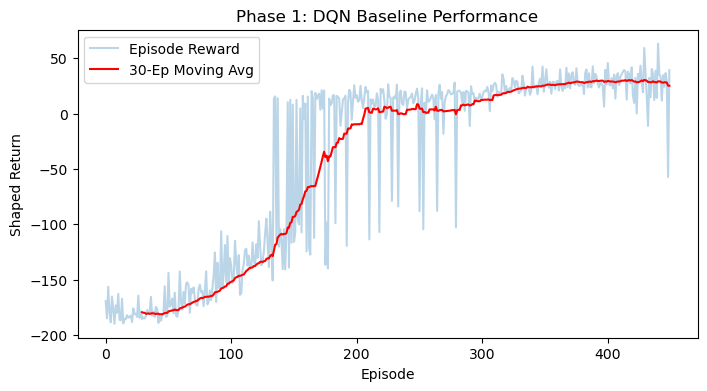

In [ ]:
import time

# --- Hyperparameters ---
EPISODES = 450
MAX_STEPS = 200 # Redundant with env's TimeLimit(truncated=True) -- Hadis Checker --
BATCH_SIZE = 64
TARGET_SYNC_FREQ = 5  # Sync target network every 5 episodes

# --- Initialization ---
env = ShapedMountainCar(gym.make('MountainCar-v0')) # Logic terminated and truncated inside the MountainCar-v0 -- Hadis Checker --
obs_dim = env.observation_space.shape[0]
act_dim = env.action_space.n

dqn_agent = DQNAgent(obs_dim, act_dim, lr=1e-3, batch_size=BATCH_SIZE)
dqn_buffer = DQNReplayBuffer(capacity=50000)

dqn_rewards = []
print("Starting DQN Baseline Training...")
start_time = time.time()

# --- Main Training Loop ---
for ep in range(1, EPISODES + 1):
    obs, _ = env.reset()
    ep_reward = 0
    
    for step in range(MAX_STEPS):
        # 1. Select action and step environment
        action = dqn_agent.select_action(obs)
        next_obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        
        # 2. Store and Train
        dqn_buffer.push(obs, action, reward, next_obs, done)
        dqn_agent.update(dqn_buffer) # If buffer is not ready returns 0.0, otherwise performs a training step -- Hadis Checker --
        
        obs = next_obs
        ep_reward += reward
        
        if done:
            break
            
    # Decay exploration rate at the end of the episode
    dqn_agent.decay_epsilon()
    
    # Sync target network periodically
    if ep % TARGET_SYNC_FREQ == 0:
        dqn_agent.sync_target_network()
        
    dqn_rewards.append(ep_reward)
    
    # Logging
    if ep % 30 == 0:
        avg_rew = np.mean(dqn_rewards[-30:])
        print(f"Episode {ep:3d} | Avg Reward (last 30): {avg_rew:7.2f} | Epsilon: {dqn_agent.epsilon:.3f}")

env.close()
print(f"DQN Training Completed in {time.time() - start_time:.2f} seconds.")

# --- Plotting the Learning Curve ---
plt.figure(figsize=(8, 4))
plt.plot(dqn_rewards, label='Episode Reward', alpha=0.3)
# Calculate moving average
moving_avg = np.convolve(dqn_rewards, np.ones(30)/30, mode='valid')
plt.plot(range(29, len(dqn_rewards)), moving_avg, color='red', label='30-Ep Moving Avg')
plt.title('Phase 1: DQN Baseline Performance')
plt.xlabel('Episode')
plt.ylabel('Shaped Return')
plt.legend()
plt.show()

# Phase 2: Proximal Policy Optimization (PPO) Baseline

### Step 1: The Actor-Critic Network and Rollout Buffer
Unlike DQN, which infers the best action from Q-values, PPO uses an **Actor-Critic** architecture:
1. **The Actor:** Looks at the state and directly outputs a probability distribution over the possible actions (the policy).
2. **The Critic:** Looks at the state and predicts the expected total reward (the value). This acts as a baseline to help the Actor learn if an action was better or worse than expected.

Because PPO is on-policy, we replace the standard Replay Buffer with a **Rollout Buffer**. The agent collects a fixed trajectory of experiences, uses Generalized Advantage Estimation (GAE) to calculate how good each action was (the "Advantage"), and then uses this batch to update the networks.

In [4]:
import scipy.signal
from torch.distributions.categorical import Categorical

# --- 1. Math Helper for GAE ---
def discount_cumsum(x, discount):
    """Calculates the discounted cumulative sum (used for returns and advantages)."""
    return scipy.signal.lfilter([1], [1, float(-discount)], x[::-1], axis=0)[::-1]

# --- 2. The Actor-Critic Network ---
class PPONetwork(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden_size=64):
        super(PPONetwork, self).__init__()
        # Actor: Outputs logits for categorical distribution
        self.actor = nn.Sequential(
            nn.Linear(obs_dim, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, act_dim)
        )
        # Critic: Outputs a single value estimate
        self.critic = nn.Sequential(
            nn.Linear(obs_dim, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1)
        )

    def get_action(self, obs):
        """Called during environment interaction."""
        logits = self.actor(obs)
        dist = Categorical(logits=logits)
        action = dist.sample()
        val = self.critic(obs).squeeze(-1)
        return action.item(), dist.log_prob(action), val

    def evaluate(self, obs, action):
        """Called during network update to get log probabilities and entropy."""
        logits = self.actor(obs)
        dist = Categorical(logits=logits)
        log_prob = dist.log_prob(action)
        entropy = dist.entropy()
        val = self.critic(obs).squeeze(-1)
        return log_prob, val, entropy

# --- 3. The PPO Rollout Buffer ---
class PPORolloutBuffer:
    def __init__(self, size, obs_dim, gamma=0.99, lam=0.95):
        self.obs_buf = np.zeros((size, obs_dim), dtype=np.float32)
        self.act_buf = np.zeros(size, dtype=np.float32)
        self.adv_buf = np.zeros(size, dtype=np.float32)
        self.rew_buf = np.zeros(size, dtype=np.float32)
        self.ret_buf = np.zeros(size, dtype=np.float32)
        self.val_buf = np.zeros(size, dtype=np.float32)
        self.logp_buf = np.zeros(size, dtype=np.float32)
        
        self.gamma, self.lam = gamma, lam
        self.ptr, self.path_start_idx, self.max_size = 0, 0, size

    def store(self, obs, act, rew, val, logp):
        assert self.ptr < self.max_size
        self.obs_buf[self.ptr] = obs
        self.act_buf[self.ptr] = act
        self.rew_buf[self.ptr] = rew
        self.val_buf[self.ptr] = val
        self.logp_buf[self.ptr] = logp
        self.ptr += 1

    def finish_path(self, last_val=0):
        """Calculates GAE and returns for the current episode trajectory."""
        path_slice = slice(self.path_start_idx, self.ptr)
        rews = np.append(self.rew_buf[path_slice], last_val)
        vals = np.append(self.val_buf[path_slice], last_val)
        
        # Calculate GAE-Lambda Advantage
        deltas = rews[:-1] + self.gamma * vals[1:] - vals[:-1]
        self.adv_buf[path_slice] = discount_cumsum(deltas, self.gamma * self.lam)
        
        # Calculate Returns
        self.ret_buf[path_slice] = discount_cumsum(rews, self.gamma)[:-1]
        self.path_start_idx = self.ptr

    def get(self):
        """Returns the fully populated buffer and resets pointers."""
        assert self.ptr == self.max_size
        self.ptr, self.path_start_idx = 0, 0
        
        # Normalize advantages for stability
        adv_mean = np.mean(self.adv_buf)
        adv_std = np.std(self.adv_buf)
        self.adv_buf = (self.adv_buf - adv_mean) / (adv_std + 1e-8)
        
        data = dict(obs=self.obs_buf, act=self.act_buf, ret=self.ret_buf,
                    adv=self.adv_buf, logp=self.logp_buf)
        return {k: torch.as_tensor(v, dtype=torch.float32) for k, v in data.items()}

print("PPO Network and Buffer Initialized Successfully!")

PPO Network and Buffer Initialized Successfully!


### Step 2: The PPO Update Logic (Clipped Surrogate Objective)
Standard policy gradient methods suffer from instability: if an update step is too large, the policy can "fall off a cliff" and forget how to play. 

PPO solves this by introducing a **Clipping Mechanism**. When we update the Actor network, we calculate a `ratio` between the new policy and the old policy. PPO explicitly clips this ratio between $1-\epsilon$ and $1+\epsilon$ (usually 0.8 and 1.2). 
* If an action was good (positive advantage), the probability of taking it increases, but it is "capped" so it doesn't increase too aggressively.
* We also add a small **Entropy Bonus** to encourage the agent to remain slightly random, preventing it from converging on a bad strategy too early.

The Critic network is simply updated using Mean Squared Error (MSE) to match the actual returns collected in the buffer.

In [5]:
# --- PPO Update Hyperparameters ---
CLIP_RATIO = 0.2
PI_LR = 3e-4     # Learning rate for the Actor (Policy)
VF_LR = 1e-3     # Learning rate for the Critic (Value Function)
TRAIN_PI_ITERS = 80 # Number of gradient steps for the Actor per epoch
TRAIN_V_ITERS = 80  # Number of gradient steps for the Critic per epoch

# Initialize the network and separate optimizers
ppo_net = PPONetwork(obs_dim=2, act_dim=3)
pi_optimizer = optim.Adam(ppo_net.actor.parameters(), lr=PI_LR)
v_optimizer = optim.Adam(ppo_net.critic.parameters(), lr=VF_LR)

def ppo_update(buffer):
    """Retrieves data from the buffer and performs the PPO network updates."""
    # Retrieve all collected data from the current epoch
    data = buffer.get()
    obs, act, adv = data['obs'], data['act'], data['adv']
    ret, logp_old = data['ret'], data['logp']

    # --- 1. Update the Actor (Policy) ---
    for _ in range(TRAIN_PI_ITERS):
        pi_optimizer.zero_grad()
        logp, _, entropy = ppo_net.evaluate(obs, act)
        
        # Calculate the probability ratio: pi_theta / pi_theta_old
        ratio = torch.exp(logp - logp_old)
        
        # Calculate the Clipped Surrogate Objective
        clip_adv = torch.clamp(ratio, 1.0 - CLIP_RATIO, 1.0 + CLIP_RATIO) * adv
        
        # We maximize the objective by minimizing its negative, plus an entropy bonus
        loss_pi = -(torch.min(ratio * adv, clip_adv)).mean() - 0.01 * entropy.mean()
        
        loss_pi.backward()
        pi_optimizer.step()

    # --- 2. Update the Critic (Value Function) ---
    for _ in range(TRAIN_V_ITERS):
        v_optimizer.zero_grad()
        _, val, _ = ppo_net.evaluate(obs, act)
        
        # Simple Mean Squared Error against the actual returns
        loss_v = F.mse_loss(val, ret)
        
        loss_v.backward()
        v_optimizer.step()
        
    return loss_pi.item(), loss_v.item()

print("PPO Update Logic successfully established!")

PPO Update Logic successfully established!


### Step 3: The PPO Training Loop
Unlike DQN, which trains in *Episodes* (one game from start to finish), PPO trains in **Epochs**. 

During a single epoch, the agent collects a fixed number of steps (e.g., 4000) regardless of how many times the game ends or restarts. Once the buffer hits 4000 steps, it calculates the Generalized Advantage Estimation (GAE) for all trajectories, runs the `ppo_update` function, and wipes the buffer completely clean for the next epoch.

Starting PPO Baseline Training...
Epoch  5 | Avg Reward: -169.53 | Pi Loss: -0.012 | V Loss: 812.620
Epoch 10 | Avg Reward: -166.96 | Pi Loss: -0.010 | V Loss: 460.021
Epoch 15 | Avg Reward: -160.27 | Pi Loss: -0.010 | V Loss: 409.755
Epoch 20 | Avg Reward: -170.61 | Pi Loss: -0.013 | V Loss: 442.869
Epoch 25 | Avg Reward: -166.65 | Pi Loss: -0.012 | V Loss: 422.540
Epoch 30 | Avg Reward: -168.14 | Pi Loss: -0.011 | V Loss: 433.134
Epoch 35 | Avg Reward: -161.33 | Pi Loss: -0.008 | V Loss: 399.377
Epoch 40 | Avg Reward: -161.22 | Pi Loss: -0.010 | V Loss: 397.487
Epoch 45 | Avg Reward: -153.80 | Pi Loss: -0.007 | V Loss: 357.472
Epoch 50 | Avg Reward: -155.44 | Pi Loss: -0.006 | V Loss: 360.041
Epoch 55 | Avg Reward: -155.75 | Pi Loss: -0.007 | V Loss: 372.325
Epoch 60 | Avg Reward: -155.97 | Pi Loss: -0.007 | V Loss: 364.234
Epoch 65 | Avg Reward: -153.16 | Pi Loss: -0.008 | V Loss: 298.164
Epoch 70 | Avg Reward: -156.03 | Pi Loss: -0.011 | V Loss: 300.740
Epoch 75 | Avg Reward: -156.

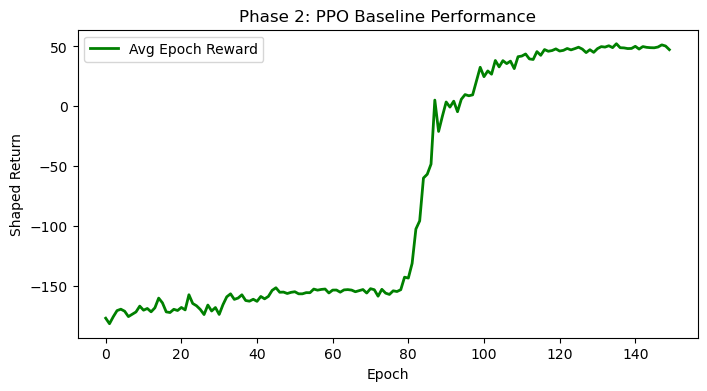

In [6]:
# --- PPO Training Hyperparameters ---
EPOCHS = 150
STEPS_PER_EPOCH = 4000
MAX_EP_LEN = 200

# We use the exact same Shaped Environment from Phase 1 for a fair comparison!
env = ShapedMountainCar(gym.make('MountainCar-v0'))
ppo_buffer = PPORolloutBuffer(STEPS_PER_EPOCH, obs_dim=2)

ppo_epoch_returns = []
obs, _ = env.reset()
ep_ret, ep_len = 0, 0

print("Starting PPO Baseline Training...")
start_time = time.time()

# --- Main PPO Loop ---
for epoch in range(EPOCHS):
    epoch_rets = [] # Track rewards for completed episodes in this epoch
    
    # 1. Collect a fixed chunk of experience (Rollout)
    for t in range(STEPS_PER_EPOCH):
        with torch.no_grad():
            obs_tensor = torch.as_tensor(obs, dtype=torch.float32)
            act, logp, val = ppo_net.get_action(obs_tensor)
            
        next_obs, rew, term, trunc, _ = env.step(act)
        ep_ret += rew
        ep_len += 1
        
        # Store in buffer
        ppo_buffer.store(obs, act, rew, val.item(), logp.item())
        obs = next_obs
        
        timeout = ep_len == MAX_EP_LEN
        terminal = term or trunc
        epoch_ended = t == STEPS_PER_EPOCH - 1
        
        # 2. If trajectory ends, finish path and calculate GAE
        if terminal or epoch_ended:
            if epoch_ended and not terminal:
                # Bootstrap the value if the epoch cut the episode off early
                with torch.no_grad():
                    obs_tensor = torch.as_tensor(obs, dtype=torch.float32)
                    _, _, val = ppo_net.get_action(obs_tensor)
            else:
                val = 0
                
            ppo_buffer.finish_path(last_val=val)
            
            if terminal:
                epoch_rets.append(ep_ret)
                
            obs, _ = env.reset()
            ep_ret, ep_len = 0, 0

    # 3. Update Networks with the collected Rollout
    loss_pi, loss_v = ppo_update(ppo_buffer)
    
    # Logging
    avg_ep_ret = np.mean(epoch_rets) if epoch_rets else 0
    ppo_epoch_returns.append(avg_ep_ret)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:2d} | Avg Reward: {avg_ep_ret:7.2f} | Pi Loss: {loss_pi:6.3f} | V Loss: {loss_v:6.3f}")

env.close()
print(f"PPO Training Completed in {time.time() - start_time:.2f} seconds.")

# --- Plotting the Learning Curve ---
plt.figure(figsize=(8, 4))
plt.plot(ppo_epoch_returns, label='Avg Epoch Reward', color='green', linewidth=2)
plt.title('Phase 2: PPO Baseline Performance')
plt.xlabel('Epoch')
plt.ylabel('Shaped Return')
plt.legend()
plt.show()

# Phase 3: Safe PPO (Constrained Markov Decision Process)

### Step 1: Soft Constraints and the Dual-Critic Network
In our final phase, we transition the environment into a Constrained MDP. We introduce a `max_speed` limit. If the agent exceeds this limit, it incurs a **proportional safety cost** (the faster it goes over the limit, the higher the penalty). 

To process this, we upgrade our PPO agent to a **Dual-Critic Architecture**:
1. **The Actor:** Outputs the action probabilities.
2. **The Reward Critic:** Predicts the expected standard return ($V_R$).
3. **The Cost Critic:** Predicts the expected safety penalty ($V_C$).

In [7]:
# --- 1. The CMDP Environment with Soft Constraints ---
class ConstrainedMountainCar(gym.Wrapper):
    """
    Adds reward shaping, a massive completion bonus, and a proportional 
    safety cost for exceeding the speed limit.
    """
    def __init__(self, env, max_speed=0.04):
        super().__init__(env)
        self.max_speed = max_speed
        
    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        velocity = abs(obs[1])
        
        # 1. Soft Safety Constraint: Proportional penalty for speeding
        if velocity > self.max_speed:
            cost = (velocity - self.max_speed) * 100.0 
        else:
            cost = 0.0
            
        # 2. Reward Shaping & Completion Bonus
        height_bonus = abs(obs[0] - (-0.5)) * 1.5
        shaped_reward = reward + height_bonus
        if terminated:
            shaped_reward += 100.0
            
        info['cost'] = cost
        return obs, shaped_reward, terminated, truncated, info

# --- 2. The Dual-Critic Network ---
class SafePPONetwork(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden_size=64):
        super(SafePPONetwork, self).__init__()
        
        self.actor = nn.Sequential(
            nn.Linear(obs_dim, hidden_size), nn.Tanh(),
            nn.Linear(hidden_size, hidden_size), nn.Tanh(),
            nn.Linear(hidden_size, act_dim)
        )
        self.reward_critic = nn.Sequential(
            nn.Linear(obs_dim, hidden_size), nn.Tanh(),
            nn.Linear(hidden_size, hidden_size), nn.Tanh(),
            nn.Linear(hidden_size, 1)
        )
        self.cost_critic = nn.Sequential(
            nn.Linear(obs_dim, hidden_size), nn.Tanh(),
            nn.Linear(hidden_size, hidden_size), nn.Tanh(),
            nn.Linear(hidden_size, 1)
        )

    def get_action(self, obs):
        logits = self.actor(obs)
        dist = Categorical(logits=logits)
        action = dist.sample()
        v_r = self.reward_critic(obs).squeeze(-1)
        v_c = self.cost_critic(obs).squeeze(-1)
        return action.item(), dist.log_prob(action), v_r, v_c

    def evaluate(self, obs, action):
        logits = self.actor(obs)
        dist = Categorical(logits=logits)
        log_prob = dist.log_prob(action)
        entropy = dist.entropy()
        v_r = self.reward_critic(obs).squeeze(-1)
        v_c = self.cost_critic(obs).squeeze(-1)
        return log_prob, v_r, v_c, entropy

print("Safe Environment and Dual-Critic Network Initialized!")

Safe Environment and Dual-Critic Network Initialized!


### Step 2: The Dual-Advantage Rollout Buffer
Because our environment now emits both a reward and a safety cost, our buffer must track both signals and calculate two separate sets of Advantages:
1. **Reward Advantage ($A_R$):** Used to maximize our progress toward the flag. We normalize this (mean 0, std 1) so the network easily distinguishes "better than average" actions from "worse than average" actions.
2. **Cost Advantage ($A_C$):** Used to penalize the agent if it exceeds the proportional speed limit. We only scale this by standard deviation; we **do not** mean-center it because a cost of 0 is an absolute metric of safety.

In [8]:
class SafePPORolloutBuffer:
    """
    A buffer for storing trajectories experienced by a Safe PPO agent.
    Computes GAE for both the standard reward and the safety cost.
    """
    def __init__(self, size, obs_dim, gamma=0.99, lam=0.95):
        self.obs_buf = np.zeros((size, obs_dim), dtype=np.float32)
        self.act_buf = np.zeros(size, dtype=np.float32)
        self.logp_buf = np.zeros(size, dtype=np.float32)
        
        # --- Reward Tracking Arrays ---
        self.rew_buf = np.zeros(size, dtype=np.float32)
        self.val_r_buf = np.zeros(size, dtype=np.float32)
        self.adv_r_buf = np.zeros(size, dtype=np.float32)
        self.ret_r_buf = np.zeros(size, dtype=np.float32)
        
        # --- Cost Tracking Arrays ---
        self.cost_buf = np.zeros(size, dtype=np.float32)
        self.val_c_buf = np.zeros(size, dtype=np.float32)
        self.adv_c_buf = np.zeros(size, dtype=np.float32)
        self.ret_c_buf = np.zeros(size, dtype=np.float32)
        
        self.gamma, self.lam = gamma, lam
        self.ptr, self.path_start_idx, self.max_size = 0, 0, size

    def store(self, obs, act, rew, cost, val_r, val_c, logp):
        assert self.ptr < self.max_size
        self.obs_buf[self.ptr] = obs
        self.act_buf[self.ptr] = act
        self.rew_buf[self.ptr] = rew
        self.cost_buf[self.ptr] = cost
        self.val_r_buf[self.ptr] = val_r
        self.val_c_buf[self.ptr] = val_c
        self.logp_buf[self.ptr] = logp
        self.ptr += 1

    def finish_path(self, last_val_r=0, last_val_c=0):
        path_slice = slice(self.path_start_idx, self.ptr)
        
        # 1. Calculate GAE and Returns for Rewards
        rews = np.append(self.rew_buf[path_slice], last_val_r)
        vals_r = np.append(self.val_r_buf[path_slice], last_val_r)
        deltas_r = rews[:-1] + self.gamma * vals_r[1:] - vals_r[:-1]
        self.adv_r_buf[path_slice] = discount_cumsum(deltas_r, self.gamma * self.lam)
        self.ret_r_buf[path_slice] = discount_cumsum(rews, self.gamma)[:-1]
        
        # 2. Calculate GAE and Returns for Costs
        costs = np.append(self.cost_buf[path_slice], last_val_c)
        vals_c = np.append(self.val_c_buf[path_slice], last_val_c)
        deltas_c = costs[:-1] + self.gamma * vals_c[1:] - vals_c[:-1]
        self.adv_c_buf[path_slice] = discount_cumsum(deltas_c, self.gamma * self.lam)
        self.ret_c_buf[path_slice] = discount_cumsum(costs, self.gamma)[:-1]
        
        self.path_start_idx = self.ptr

    def get(self):
        assert self.ptr == self.max_size
        self.ptr, self.path_start_idx = 0, 0
        
        # Normalize Reward Advantage
        adv_r_mean = np.mean(self.adv_r_buf)
        adv_r_std = np.std(self.adv_r_buf)
        self.adv_r_buf = (self.adv_r_buf - adv_r_mean) / (adv_r_std + 1e-8)
        
        # Scale Cost Advantage (Do NOT mean-center)
        self.adv_c_buf = self.adv_c_buf / (np.std(self.adv_c_buf) + 1e-8)

        data = dict(obs=self.obs_buf, act=self.act_buf, logp=self.logp_buf,
                    ret_r=self.ret_r_buf, ret_c=self.ret_c_buf, 
                    adv_r=self.adv_r_buf, adv_c=self.adv_c_buf)
        
        return {k: torch.as_tensor(v, dtype=torch.float32) for k, v in data.items()}

print("Safe Rollout Buffer Initialized Successfully!")

Safe Rollout Buffer Initialized Successfully!


### Step 3: The PPO-Lagrangian Update
This is where the agent balances its desire to reach the flag against its fear of breaking the speed limit.

1. **The Policy Loss:** We calculate the standard PPO Clipped Surrogate Objective for the Reward ($A_R$). Then, we subtract the Cost Penalty ($A_C$), scaled by our dynamic Lagrangian Multiplier ($\lambda$). 
2. **The Critics Loss:** Both the Reward Critic and the Cost Critic are updated using simple Mean Squared Error against their respective returns.
3. **The Adaptive Lambda (The "Fear" Parameter):** Instead of a fixed penalty, $\lambda$ is a learnable parameter. We give the agent a `COST_LIMIT` of 15.0 per epoch. If the agent's average speed penalty exceeds 15.0, we use gradient ascent to increase $\lambda$—making the agent more afraid of speeding. If it drives safely under the limit, $\lambda$ decreases, allowing it to focus on reaching the flag faster.

In [9]:
# --- Safe PPO Hyperparameters ---
CLIP_RATIO = 0.2
PI_LR = 3e-4
VF_LR = 1e-3
LAM_LR = 5e-3      # Learning rate for the Lambda multiplier
COST_LIMIT = 15.0  # The Soft Cost Budget!

# Initialize the 3-headed network and optimizers
safe_net = SafePPONetwork(obs_dim=2, act_dim=3)

pi_optimizer = optim.Adam(safe_net.actor.parameters(), lr=PI_LR)
v_r_optimizer = optim.Adam(safe_net.reward_critic.parameters(), lr=VF_LR)
v_c_optimizer = optim.Adam(safe_net.cost_critic.parameters(), lr=VF_LR)

# We optimize the log of lambda for numerical stability (forces lambda to stay positive)
# We initialize it at -3.0 (approx 0.05) so the agent prioritizes the flag first.
log_lambda = torch.tensor(-3.0, requires_grad=True)
lambda_optimizer = optim.Adam([log_lambda], lr=LAM_LR)

def safe_ppo_update(buffer):
    global log_lambda
    
    # Retrieve dual-advantage data
    data = buffer.get()
    obs, act, logp_old = data['obs'], data['act'], data['logp']
    adv_r, adv_c = data['adv_r'], data['adv_c']
    ret_r, ret_c = data['ret_r'], data['ret_c']

    current_lambda = torch.exp(log_lambda).item()

    # --- 1. Train Policy Network (Actor) ---
    for _ in range(80):
        pi_optimizer.zero_grad()
        logp, _, _, entropy = safe_net.evaluate(obs, act)
        
        ratio = torch.exp(logp - logp_old)
        
        # Reward Objective
        clip_adv_r = torch.clamp(ratio, 1.0 - CLIP_RATIO, 1.0 + CLIP_RATIO) * adv_r
        obj_r = torch.min(ratio * adv_r, clip_adv_r).mean()
        
        # Cost Objective
        obj_c = (ratio * adv_c).mean()
        
        # The Lagrangian Fusion Loss! 
        loss_pi = -(obj_r - current_lambda * obj_c) - 0.01 * entropy.mean()
        
        loss_pi.backward()
        pi_optimizer.step()

    # --- 2. Train Value Networks (Dual-Critics) ---
    for _ in range(80):
        v_r_optimizer.zero_grad()
        v_c_optimizer.zero_grad()
        
        _, v_r, v_c, _ = safe_net.evaluate(obs, act)
        
        loss_v_r = F.mse_loss(v_r, ret_r)
        loss_v_c = F.mse_loss(v_c, ret_c)
        
        loss_v_r.backward()
        v_r_optimizer.step()
        
        loss_v_c.backward()
        v_c_optimizer.step()

    # --- 3. Update Adaptive Lagrangian Multiplier (lambda) ---
    lambda_optimizer.zero_grad()
    actual_batch_cost = ret_c.mean().item()
    
    # If the actual cost is higher than our limit, this loss pushes lambda UP.
    loss_lambda = -torch.exp(log_lambda) * (actual_batch_cost - COST_LIMIT)
    loss_lambda.backward()
    lambda_optimizer.step()
    
    return loss_pi.item(), loss_v_r.item(), loss_v_c.item(), torch.exp(log_lambda).item()

print("Safe PPO Update Logic successfully established!")

Safe PPO Update Logic successfully established!


### Step 4: Safe PPO Main Training Loop
This loop mirrors the standard PPO loop but handles the dual nature of our environment. 

1. **Epoch Collection:** The agent interacts with the `ConstrainedMountainCar` environment for 4000 steps.
2. **Dual Tracking:** We track both the `ep_ret_r` (reward progress toward the flag) and `ep_ret_c` (safety penalty incurred).
3. **PPO-Lagrangian Update:** At the end of the epoch, we pass the data to our safe update function.
4. **Logging:** We print the average Return, average Cost, and the current Lambda multiplier to monitor how the agent balances reaching the goal against obeying the speed limit.

Starting Safe PPO Training...
Epoch  5 | Avg Reward: -169.95 | Avg Cost:  0.00 | Lambda: 0.049
Epoch 10 | Avg Reward: -163.16 | Avg Cost:  0.00 | Lambda: 0.047
Epoch 15 | Avg Reward: -163.46 | Avg Cost:  0.00 | Lambda: 0.046
Epoch 20 | Avg Reward: -163.23 | Avg Cost:  0.00 | Lambda: 0.045
Epoch 25 | Avg Reward: -163.74 | Avg Cost:  0.00 | Lambda: 0.044
Epoch 30 | Avg Reward: -160.96 | Avg Cost:  0.00 | Lambda: 0.043
Epoch 35 | Avg Reward: -166.81 | Avg Cost:  0.00 | Lambda: 0.042
Epoch 40 | Avg Reward: -158.41 | Avg Cost:  0.00 | Lambda: 0.041
Epoch 45 | Avg Reward: -160.92 | Avg Cost:  0.00 | Lambda: 0.040
Epoch 50 | Avg Reward: -157.01 | Avg Cost:  0.00 | Lambda: 0.039
Epoch 55 | Avg Reward: -160.57 | Avg Cost:  0.00 | Lambda: 0.038
Epoch 60 | Avg Reward: -160.58 | Avg Cost:  0.00 | Lambda: 0.037
Epoch 65 | Avg Reward: -149.78 | Avg Cost:  0.00 | Lambda: 0.036
Epoch 70 | Avg Reward: -149.53 | Avg Cost:  0.00 | Lambda: 0.036
Epoch 75 | Avg Reward: -149.74 | Avg Cost:  0.00 | Lambda: 0

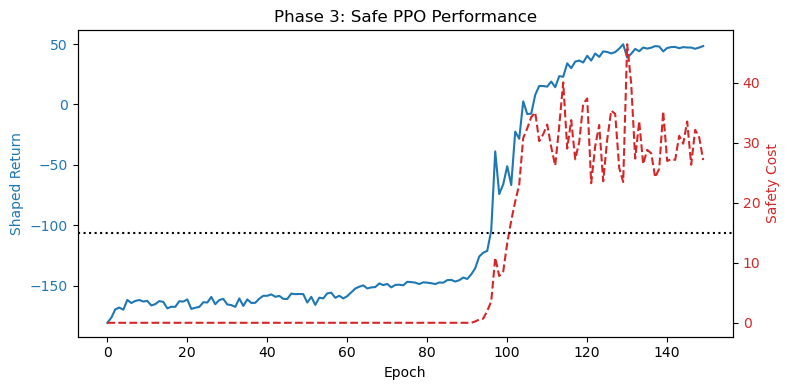

In [10]:
# --- Safe PPO Training Hyperparameters ---
EPOCHS = 150
STEPS_PER_EPOCH = 4000
MAX_EP_LEN = 200

# Initialize the Constrained Environment and Safe Buffer
env = ConstrainedMountainCar(gym.make('MountainCar-v0'), max_speed=0.04)
safe_buffer = SafePPORolloutBuffer(STEPS_PER_EPOCH, obs_dim=2)

safe_epoch_returns = []
safe_epoch_costs = []

obs, _ = env.reset()
ep_ret_r, ep_ret_c, ep_len = 0, 0, 0

print("Starting Safe PPO Training...")
start_time = time.time()

# --- Main Safe PPO Loop ---
for epoch in range(EPOCHS):
    epoch_rets = []
    epoch_costs = []
    
    # 1. Collect Rollout
    for t in range(STEPS_PER_EPOCH):
        with torch.no_grad():
            obs_tensor = torch.as_tensor(obs, dtype=torch.float32)
            act, logp, v_r, v_c = safe_net.get_action(obs_tensor)
            
        next_obs, rew, term, trunc, info = env.step(act)
        cost = info.get('cost', 0.0)
        
        ep_ret_r += rew
        ep_ret_c += cost
        ep_len += 1
        
        safe_buffer.store(obs, act, rew, cost, v_r.item(), v_c.item(), logp.item())
        obs = next_obs
        
        timeout = ep_len == MAX_EP_LEN
        terminal = term or trunc
        epoch_ended = t == STEPS_PER_EPOCH - 1
        
        # 2. Finish Path and Calculate Dual-GAE
        if terminal or epoch_ended:
            if epoch_ended and not terminal:
                with torch.no_grad():
                    obs_tensor = torch.as_tensor(obs, dtype=torch.float32)
                    _, _, v_r, v_c = safe_net.get_action(obs_tensor)
            else:
                v_r, v_c = 0, 0
                
            safe_buffer.finish_path(last_val_r=v_r, last_val_c=v_c)
            
            if terminal:
                epoch_rets.append(ep_ret_r)
                epoch_costs.append(ep_ret_c)
                
            obs, _ = env.reset()
            ep_ret_r, ep_ret_c, ep_len = 0, 0, 0

    # 3. Update Safe Networks
    loss_pi, loss_v_r, loss_v_c, current_lambda = safe_ppo_update(safe_buffer)
    
    # Logging
    avg_ep_ret = np.mean(epoch_rets) if epoch_rets else 0
    avg_ep_cost = np.mean(epoch_costs) if epoch_costs else 0
    
    safe_epoch_returns.append(avg_ep_ret)
    safe_epoch_costs.append(avg_ep_cost)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:2d} | Avg Reward: {avg_ep_ret:7.2f} | Avg Cost: {avg_ep_cost:5.2f} | Lambda: {current_lambda:5.3f}")

env.close()
print(f"Safe PPO Training Completed in {time.time() - start_time:.2f} seconds.")

# --- Plotting the Safe Learning Curve ---
fig, ax1 = plt.subplots(figsize=(8, 4))

color = 'tab:blue'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Shaped Return', color=color)
ax1.plot(safe_epoch_returns, color=color, label='Return (Goal)')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Safety Cost', color=color)  
ax2.plot(safe_epoch_costs, color=color, linestyle='--', label='Cost (Speeding)')
ax2.axhline(y=15.0, color='black', linestyle=':', label='Cost Budget Limit')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Phase 3: Safe PPO Performance')
fig.tight_layout()  
plt.show()